# Fashion MNIST Image Classification using CNN

**Problem Statement:**  
Design and implement a Convolutional Neural Network (CNN) to perform image classification using the Fashion MNIST dataset.

### What is Fashion MNIST?
- **70,000** grayscale images of clothing items (**28 × 28 pixels** each)
- **10 Classes:** T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle Boot
- **60,000** training images + **10,000** test images

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Step 2: Load the Dataset

We have **two ways** to load Fashion MNIST .  
**One method is commented out** → just uncomment to switch.

**Way 1** — Keras Built-in (Easiest, no download needed)  
Keras auto-downloads and caches the dataset the first time.

**Way 2** — Kaggle CSV (Download manually)
> Dataset: https://www.kaggle.com/datasets/zalando-research/fashionmnist  
> Place `fashion-mnist_train.csv` and `fashion-mnist_test.csv` in the **same folder** as this notebook.  
> **CSV Format:** First column = label (0–9), remaining 784 columns = pixel values (28×28 flattened).

In [5]:
# WAY 1: Keras built-in dataset (recommended — no download)
from tensorflow.keras.datasets import fashion_mnist

In [6]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 11us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [39]:
# WAY 2: CSV

# train_df = pd.read_csv('fashion-mnist_train.csv')
# test_df  = pd.read_csv('fashion-mnist_test.csv')

# X_train = train_df.drop('label', axis=1).values.reshape(-1, 28, 28)
# y_train = train_df['label'].values

# X_test  = test_df.drop('label', axis=1).values.reshape(-1, 28, 28)
# y_test  = test_df['label'].values

In [10]:
print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

Training samples: (60000, 28, 28)
Test samples: (10000, 28, 28)


In [11]:
# Class names for the 10 clothing categories
class_names = [ 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

In [12]:
print("Total classes  :", len(class_names))

Total classes  : 10


In [13]:
print("Image size      :", X_train.shape[1], "x", X_train.shape[2], "pixels")

Image size      : 28 x 28 pixels


## Step 3: Visualize Sample Images

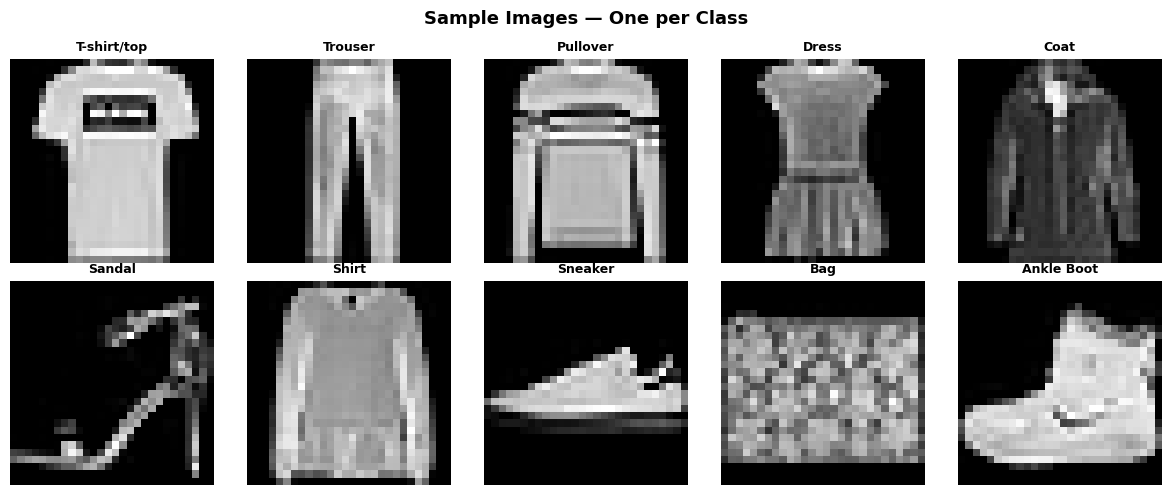

In [15]:
# Show one sample image from each of the 10 classes
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    idx = np.where(y_train == i)[0][0]   # first image of class i
    axes[i].imshow(X_train[idx], cmap='gray')
    axes[i].set_title(class_names[i], fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Images — One per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

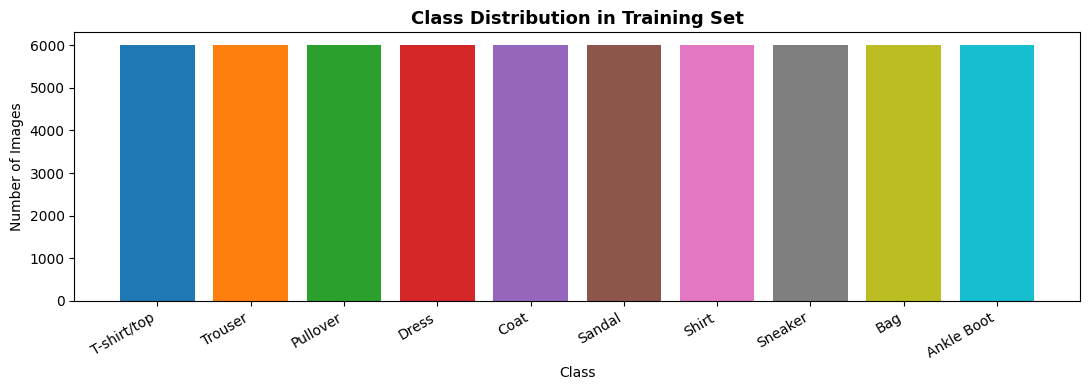

Each class has: 6000 images  → Perfectly balanced dataset!


In [16]:
# Class distribution — are all classes equally represented?
unique, counts = np.unique(y_train, return_counts=True)

colors = plt.cm.tab10(np.linspace(0, 1, 10))   # 10 distinct colors

plt.figure(figsize=(11, 4))
plt.bar(class_names, counts, color=colors)
plt.title('Class Distribution in Training Set', fontsize=13, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("Each class has:", counts[0], "images  → Perfectly balanced dataset!")

## Step 4: Preprocess the Data

### 4a. Normalize Pixel Values
Pixels are 0–255. Dividing by 255 scales them to **0.0 – 1.0**.  
Smaller values → faster, more stable training.

In [17]:
# Normalize: scale pixel values from 0-255 to 0.0-1.0
X_train = X_train / 255.0
X_test  = X_test  / 255.0

In [18]:
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Min pixel value: 0.0
Max pixel value: 1.0


### 4b. Reshape for CNN Input
CNNs expect shape `(samples, height, width, channels)`.  
Since images are **grayscale** (1 color channel), we add that dimension: `(N, 28, 28, 1)`.

In [19]:
# Add channel dimension: (N, 28, 28) → (N, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

In [20]:
print("X_train reshaped:", X_train.shape)  
print("X_test  reshaped:", X_test.shape)    

X_train reshaped: (60000, 28, 28, 1)
X_test  reshaped: (10000, 28, 28, 1)


### 4c. One-Hot Encode the Labels
The model's output has 10 neurons (one per class).  
We convert integer labels (0–9) into binary vectors.  
Example: class `3` → `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`

In [27]:
from tensorflow.keras.utils import to_categorical

In [28]:
# One-hot encode: integer label → binary vector of length 10
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

In [29]:
print("Example (label 3)   :", y_train_cat[np.where(y_train == 3)[0][0]])

Example (label 3)   : [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


### 4d. Create a Validation Set
We hold out **10% of training data** to monitor the model during training.  

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
# Split 10% of training data as validation set
X_train_fit, X_val, y_train_fit, y_val = train_test_split(X_train, y_train_cat, test_size=0.10,random_state=42)

In [32]:
print("Training   samples:", X_train_fit.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test       samples:", X_test.shape[0])

Training   samples: 54000
Validation samples: 6000
Test       samples: 10000


## Step 5: Build the CNN Model

### Architecture Overview

```
Input (28×28×1)
    ↓
Conv2D (32 filters, 3×3)  →  ReLU  →  MaxPooling (2×2)
    ↓
Conv2D (64 filters, 3×3)  →  ReLU  →  MaxPooling (2×2)
    ↓
Flatten
    ↓
Dense (128 neurons, ReLU)  →  Dropout (30%)
    ↓
Output: Dense (10 neurons, Softmax)
```

| Layer | Purpose |
|-------|---------|
| **Conv2D** | Learns visual features (edges, shapes, textures) |
| **MaxPooling2D** | Reduces image size, keeps important features |
| **Flatten** | Converts 2D feature maps → 1D vector |
| **Dense** | Fully-connected layer for classification |
| **Dropout** | Randomly drops neurons to prevent overfitting |
| **Softmax** | Outputs probability for each of the 10 classes |

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [35]:
# Build CNN model step by step
model = Sequential([

    # --- Block 1: First Convolution + Pooling ---
    # 32 filters of size 3x3 scan the image for basic features
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),    # reduces 26x26 → 13x13

    # --- Block 2: Second Convolution + Pooling ---
    # 64 filters learn more complex patterns
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),    # reduces 11x11 → 5x5

    # --- Flatten → Dense Layers ---
    Flatten(),                         # 5x5x64 = 1600 values → 1D vector
    Dense(128, activation='relu'),     # fully connected layer
    Dropout(0.3),                      # drop 30% of neurons to reduce overfitting

    # --- Output Layer: 10 classes ---
    Dense(10, activation='softmax')    # probability for each class
])


In [36]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the Model

- **Epochs:** Number of times the model sees the entire training set
- **Batch size:** Number of samples processed before updating weights
- **Validation data:** Used to check performance after each epoch (not used for training)

In [38]:
# Train the CNN model
history = model.fit( X_train_fit, y_train_fit, epochs=10, batch_size=64, validation_data=(X_val, y_val), verbose=1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8026 - loss: 0.5396 - val_accuracy: 0.8720 - val_loss: 0.3482
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8716 - loss: 0.3530 - val_accuracy: 0.8895 - val_loss: 0.3023
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.8877 - loss: 0.3057 - val_accuracy: 0.8917 - val_loss: 0.2836
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.8985 - loss: 0.2772 - val_accuracy: 0.9042 - val_loss: 0.2613
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9079 - loss: 0.2491 - val_accuracy: 0.9078 - val_loss: 0.2509
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9143 - loss: 0.2299 - val_accuracy: 0.9113 - val_loss: 0.2407
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9203 - loss: 0.2158 - val_accuracy: 0.9122 - val_loss: 0.2333
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9259 - loss: 0.1980 - 

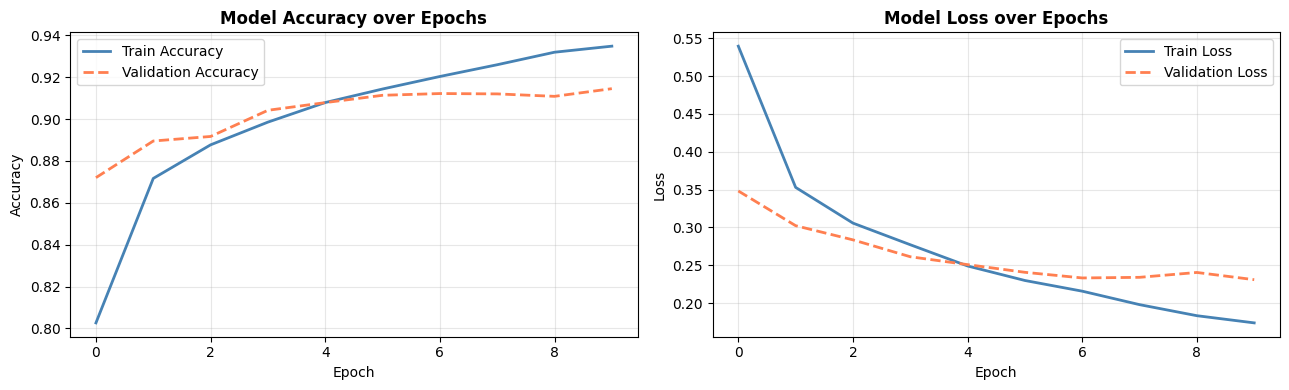

In [40]:
# Plot Training vs Validation — Accuracy and Loss
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Accuracy Plot ---
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',     color='steelblue',  linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='coral',      linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Loss Plot ---
axes[1].plot(history.history['loss'],     label='Train Loss',     color='steelblue',  linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='coral',      linewidth=2, linestyle='--')
axes[1].set_title('Model Loss over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Evaluate and Visualize Results

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

In [42]:
# Evaluate the model on the held-out test set
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

In [43]:
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss    : 0.2568
Test Accuracy: 90.82%


In [44]:
# Get predictions for the entire test set
y_pred_prob = model.predict(X_test)          # probabilities for each class
y_pred      = np.argmax(y_pred_prob, axis=1) # class with highest probability

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [45]:
# Full classification report (precision, recall, F1 per class)
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.87      0.86      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.83      0.89      0.86      1000
       Dress       0.93      0.89      0.91      1000
        Coat       0.87      0.85      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.76      0.72      0.74      1000
     Sneaker       0.96      0.94      0.95      1000
         Bag       0.96      0.98      0.97      1000
  Ankle Boot       0.94      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [46]:
# Confusion Matrix — shows which classes get confused with each other
cm = confusion_matrix(y_test, y_pred)

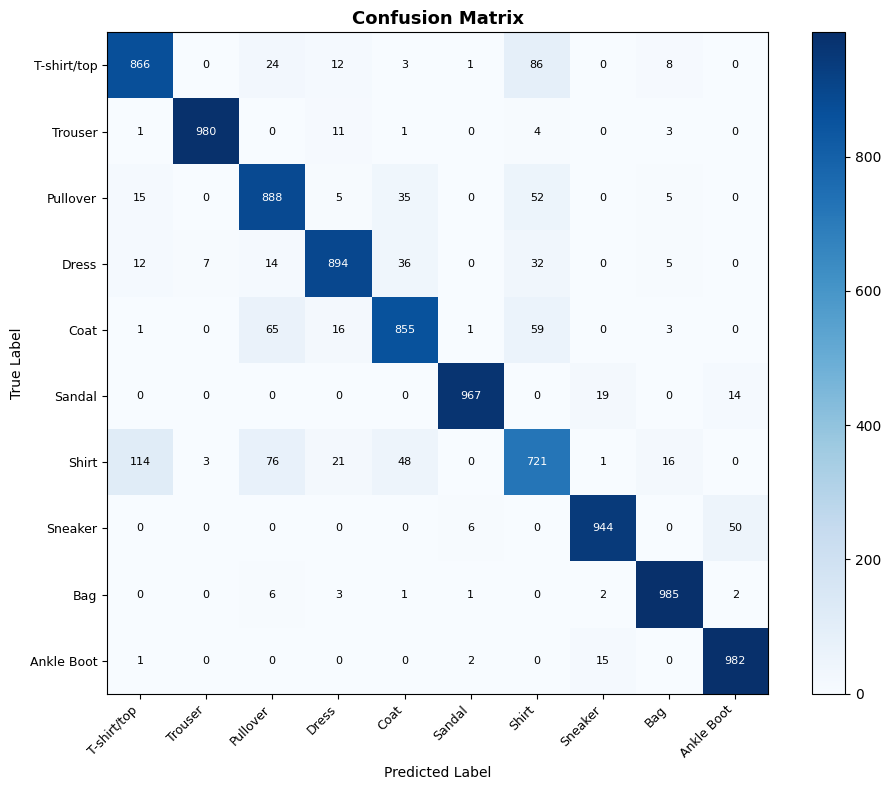

In [48]:
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xticks(range(10), class_names, rotation=45, ha='right', fontsize=9)
plt.yticks(range(10), class_names, fontsize=9)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add count numbers inside each cell
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center', fontsize=8,
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()